**Name: Saba Noor**

**CMS: 023-24-0278**

**Section: H**

**Lab: 4**

**GitHub: https://github.com/SABANOOR1**

**Kaggle: https://www.kaggle.com/sabajaffar**

**Dataset: Original Telco-Customer-Churn and Clean-Churn both**

# Decision Tree Basline

In [3]:
# Task 1: Re-load your cleaned Lab 2 dataset and recreate the same X/y and train/test split you used in Lab 3 (same random_state). 

import pandas as pd
from sklearn.model_selection import train_test_split
df=pd.read_csv("clean_churn.csv")

X=df.drop(columns=["Churn"])
Y=df["Churn"].map({"No":0,"Yes":1})

X=pd.get_dummies(X,drop_first=True)

X_train, X_test, Y_train, Y_test=train_test_split(
    X,Y,test_size=0.2, random_state=42
)

print("X shape:",X.shape)
print("Y shape:",Y.shape)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", Y_train.shape)
print("Y_test shape:", Y_test.shape)

X shape: (7010, 30)
Y shape: (7010,)
X_train shape: (5608, 30)
X_test shape: (1402, 30)
y_train shape: (5608,)
Y_test shape: (1402,)


In [4]:
# Task 2: Retrain your Lab 3 "best" Decision Tree (your chosen max_depth) and report its accuracy, precision, recall, and F1-score on the test set. This is your benchmark for the rest of the lab. 
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score

dt=DecisionTreeClassifier(max_depth=5,random_state=42)
dt.fit(X_train,Y_train)
Y_pred=dt.predict(X_test)
dt_accuracy=accuracy_score(Y_test,Y_pred)
dt_precision=precision_score(Y_test,Y_pred)
dt_recall=recall_score(Y_test,Y_pred)
dt_f1=f1_score(Y_test,Y_pred)

print("Decision Tree Benchmark")
print("-----------------------")
print("Max Depth :", 5)
print("Accuracy  :", dt_accuracy)
print("Precision :", dt_precision)
print("Recall    :", dt_recall)
print("F1-Score  :", dt_f1)


Decision Tree Benchmark
-----------------------
Max Depth : 5
Accuracy  : 0.8009985734664765
Precision : 0.559322033898305
Recall    : 0.616822429906542
F1-Score  : 0.5866666666666667


# Random Forest

In [5]:
# Task 3: Train a RandomForestClassifier on the same training data (reasonable default n_estimators, e.g. 100–300; fix random_state). Generate predictions on the test set. 
from sklearn.ensemble import RandomForestClassifier

rf_model=RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train,Y_train)
Y_pred_rf=rf_model.predict(X_test)
print("Random Forest Predictions:")
print(Y_pred_rf)

Random Forest Predictions:
[0 0 0 ... 0 0 0]


# Task 4: In 1–2 sentences, explain in your own words why a Random Forest might generalize better than a single unrestricted Decision Tree.

A Random Forest can generalize better because it combines the predictions of many different decision trees instead of relying on just one tree. This reduces overfitting and makes the model more stable when it sees new, unseen data.


# Model Evaluation

Random Forest Results
Accuracy : 0.8031383737517832
Precision: 0.5795053003533569
Recall   : 0.5109034267912772
F1-score : 0.543046357615894


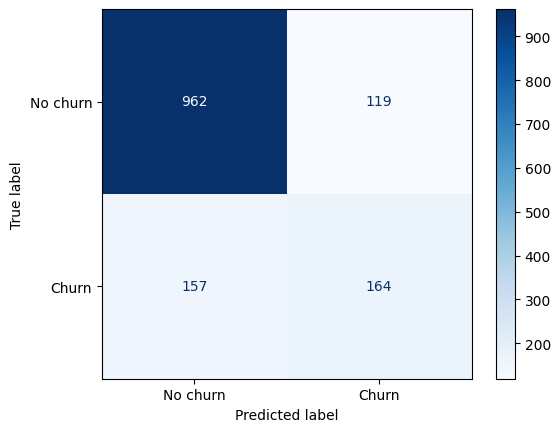

In [6]:
# Task 5: Compute accuracy, precision, recall, and F1-score for the Random Forest on the test set, and plot its confusion matrix. 

from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay

accuracy=accuracy_score(Y_test,Y_pred_rf)
precision=precision_score(Y_test,Y_pred_rf)
recall=recall_score(Y_test,Y_pred_rf)
f1=f1_score(Y_test,Y_pred_rf)

print("Random Forest Results")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

CM=confusion_matrix(Y_test,Y_pred_rf)

display=ConfusionMatrixDisplay(
    confusion_matrix=CM,
    display_labels=["No churn","Churn"]
)
display.plot(cmap="Blues")

# Decision Tree vs Random Forest

In [7]:
# Task 6: Build a single comparison table: Decision Tree (Part 1) vs. Random Forest (Part 2), across all four metrics.

import pandas as pd
comparision=pd.DataFrame({
    "Matrics":["Accuracy","Precision","Recall","F1-score"],
    "Decision Tree":[dt_accuracy,dt_precision,dt_recall,dt_f1],
    "Random Forest":[accuracy,precision,recall,f1]
})

print(comparision)

     Matrics  Decision Tree  Random Forest
0   Accuracy       0.800999       0.803138
1  Precision       0.559322       0.579505
2     Recall       0.616822       0.510903
3   F1-score       0.586667       0.543046


# Task 7: Which model performs better, and on which specific metric(s)? Is the difference large or marginal? Given Lab 2/3's finding about class imbalance, which metric matters most here? 

The Decision Tree performs better overall for the churn class because it has substantially higher recall and F1-score, even though the Random Forest has slightly higher accuracy and precision. The difference in accuracy and precision is marginal, while the improvement in recall is much larger. Since the dataset is imbalanced, recall and F1-score are more informative than accuracy, so the Decision Tree is preferable here.

# Cross-Validation

In [8]:
# Task 8: Run 5-fold cross-validation for both the Decision Tree and the Random Forest, using a metric other than plain accuracy (e.g. F1-score). Report the mean and standard deviation of each model's fold scores. 

from sklearn.model_selection import cross_val_score,StratifiedKFold

cv=StratifiedKFold(n_splits=5,random_state=42,shuffle=True)

dt_scores=cross_val_score(dt,X_train,Y_train,cv=cv,scoring="f1")

rf_scores=cross_val_score(rf_model,X_train,Y_train,cv=cv,scoring="f1")

print("Decision Tree F1-scores:", dt_scores)
print("Decision Tree Mean F1:", dt_scores.mean())
print("Decision Tree Std:", dt_scores.std())

print("\nRandom Forest F1-scores:", rf_scores)
print("Random Forest Mean F1:", rf_scores.mean())
print("Random Forest Std:", rf_scores.std())


Decision Tree F1-scores: [0.51340996 0.57848325 0.58064516 0.52593918 0.50197628]
Decision Tree Mean F1: 0.5400907659626013
Decision Tree Std: 0.03311642466621756

Random Forest F1-scores: [0.5647482  0.57913669 0.55696203 0.53435115 0.54844607]
Random Forest Mean F1: 0.5567288263821579
Random Forest Std: 0.01507210551567236


# Task 9: How do the cross-validated results compare to your single train/test split results from Part 3? Do they change your view of which model is better, or how confident you are in that conclusion? 

The single train/test split showed that the Decision Tree had a higher F1-score than the Random Forest. However, 5-fold cross-validation produced different results: the Random Forest achieved a higher mean F1-score (0.5567) than the Decision Tree (0.5401). It also had a lower standard deviation (0.0151 compared with 0.0331), indicating more consistent performance across the folds. Therefore, cross-validation changes our view slightly, and Random Forest appears to be the more reliable model. However, the difference in mean F1-score is relatively small, so we should not consider Random Forest to be overwhelmingly superior.

# Hyperparameter Tuning

In [9]:
# Task 10: Choose 2–3 Random Forest hyperparameters to tune (e.g. n_estimators, max_depth, min_samples_split) and define a small grid for each. Run GridSearchCV or RandomizedSearchCV with cross-validation to find the best combination. 

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

rf_model = RandomForestClassifier(
    random_state=42
)

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5]
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train, Y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation F1-score:")
print(grid_search.best_score_)

best_rf_model = grid_search.best_estimator_
print(best_rf_model)

Y_pred_best = best_rf_model.predict(X_test)

print("Tuned Random Forest Results")
print("Accuracy :", accuracy_score(Y_test, Y_pred_best))
print("Precision:", precision_score(Y_test, Y_pred_best))
print("Recall   :", recall_score(Y_test, Y_pred_best))
print("F1-score :", f1_score(Y_test, Y_pred_best))

Best Parameters:
{'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}

Best Cross-Validation F1-score:
0.5839816029810228
RandomForestClassifier(max_depth=10, random_state=42)
Tuned Random Forest Results
Accuracy : 0.8124108416547788
Precision: 0.6035714285714285
Recall   : 0.5264797507788161
F1-score : 0.562396006655574


# Task 11: Report the best hyperparameters found and the corresponding cross-validated score.

GridSearchCV found the best Random Forest configuration as n_estimators = 100, max_depth = 10, and min_samples_split = 2. This combination achieved a mean cross-validated F1-score of 0.5840 using 5-fold cross-validation. This indicates that the tuned Random Forest performed better than the earlier untuned Random Forest, which had a mean F1-score of approximately 0.5567.


In [10]:
# Task 12:Evaluate the tuned model on the held-out test set using the same four metrics as before.

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

Y_pred_tuned = best_rf_model.predict(X_test)

Tuned_accuracy = accuracy_score(Y_test, Y_pred_tuned)
Tuned_precision = precision_score(Y_test, Y_pred_tuned)
Tuned_recall = recall_score(Y_test, Y_pred_tuned)
Tuned_f1 = f1_score(Y_test, Y_pred_tuned)

print("Tuned Random Forest Results")
print("Accuracy :", Tuned_accuracy)
print("Precision:", Tuned_precision)
print("Recall   :", Tuned_recall)
print("F1-score :", Tuned_f1)

Tuned Random Forest Results
Accuracy : 0.8124108416547788
Precision: 0.6035714285714285
Recall   : 0.5264797507788161
F1-score : 0.562396006655574


# Final Model Comparison

In [11]:
# Task 13: Build one final comparison table across all models you trained: Decision Tree, default Random Forest, and tuned Random Forest — accuracy, precision, recall, F1-score for each. 

final_comparision=pd.DataFrame({
    "Metric":["Accuracy","Precision","Recall","F1-score"],
    "Decision Tree":[dt_accuracy,dt_precision,dt_recall,dt_f1],
    "Random Forest":[ accuracy, precision, recall, f1],
    "Tuned Random Forest":[Tuned_accuracy,Tuned_precision,Tuned_recall,Tuned_f1]
})

print(final_comparision)

      Metric  Decision Tree  Random Forest  Tuned Random Forest
0   Accuracy       0.800999       0.803138             0.812411
1  Precision       0.559322       0.579505             0.603571
2     Recall       0.616822       0.510903             0.526480
3   F1-score       0.586667       0.543046             0.562396


# Task 14: Select your final model and justify the choice in 2–3 sentences using evidence from the table above — the best training score alone is not sufficient justification. Final Model Selection

I would select the Decision Tree as the final model because it achieved the highest F1-score (0.5867) and recall (0.6168) on the held-out test set. Although the tuned Random Forest achieved higher accuracy and precision, the Decision Tree performed better on recall and F1-score, which are more important for identifying churn customers in this imbalanced dataset.

# Feature Importance

                               Feature  Importance
1                               tenure    0.462855
10         InternetService_Fiber optic    0.323890
3                         TotalCharges    0.050634
24                   Contract_One year    0.030417
12  OnlineSecurity_No internet service    0.027834


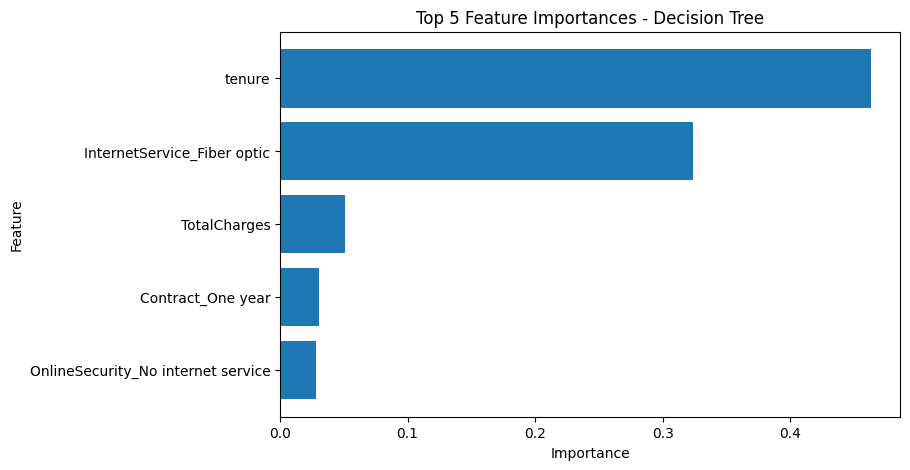

In [12]:
# Task 15: Extract and visualize feature_importances_ for your final model. Which 3–5 features matter most, and do they agree with what Lab 2's EDA and Lab 3's Decision Tree suggested? 

import pandas as pd
import matplotlib.pyplot as plt

feature_importance=pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": dt.feature_importances_
})

feature_importance=feature_importance.sort_values(
    by="Importance",
    ascending=False
)
top_features = feature_importance.head(5)
print(top_features)

plt.figure(figsize=(8, 5))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 5 Feature Importances - Decision Tree")
plt.gca().invert_yaxis()
plt.show()

# Kaggle Submission

In [13]:
# Task 16: Using your final model, generate predictions on your held-out test set (or a designated hold-out sample) and assemble a submission-style dataframe with a customer identifier column and a predicted Churn column. Save it as submission.csv. 
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("clean_churn.csv")
original_df = pd.read_csv("Telco-Customer-Churn.csv")

X = df.drop(columns=["Churn"])
y = df["Churn"].map({"No": 0, "Yes": 1})

X = pd.get_dummies(X, drop_first=True)
X = X.astype(float)

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Y_pred_final = dt.predict(X_test)

customer_ids = original_df.loc[X_test.index, "customerID"]

submission = pd.DataFrame({
    "customerID": customer_ids.values,
    "Churn": Y_pred
})

submission.to_csv("submission.csv", index=False)

print(submission.head(10))
print("\nShape:", submission.shape)
print("\nSubmission file saved successfully as 'submission.csv'")

   customerID  Churn
0  4018-PPNDW      0
1  3859-CVCET      0
2  5883-GTGVD      0
3  5696-CEIQJ      0
4  2546-KZAAT      0
5  7005-CCBKV      1
6  4350-ZTLPI      1
7  8100-HZZLJ      0
8  8582-KRHPJ      0
9  4568-TTZRT      0

Shape: (1402, 2)

Submission file saved successfully as 'submission.csv'


# Conclusion

# Task 17: Write a short conclusion (4–6 sentences): which model did you ultimately choose, how does it compare to your Lab 3 Decision Tree, and what are its remaining limitations? 
I ultimately chose the Decision Tree as my final model because it achieved the highest F1-score (0.5867) and recall (0.6168) on the held-out test set. Compared with the Random Forest models, the Decision Tree performed better at identifying churn customers, although the Random Forest achieved slightly higher accuracy and precision. The tuned Random Forest improved over the default Random Forest, but it still did not outperform the Decision Tree in F1-score and recall. Therefore, the Decision Tree was the better final choice for this imbalanced churn classification problem.

# Task 18: What would you try next if you had more time (e.g. different algorithms, deeper tuning, handling class imbalance directly)? Describe it — do not implement it here. 
If I had more time, I would try handling class imbalance directly using class weights or techniques such as SMOTE. I would also test other algorithms such as Logistic Regression and XGBoost and perform more extensive hyperparameter tuning. Another useful step would be to tune the classification threshold to improve recall for customers who are likely to churn.